# Audio Fingerprinting on FMA-small

End-to-end implementation of the landmark-hashing algorithm from Wang (2003),
applied to the [FMA-small](https://github.com/mdeff/fma) dataset.
Course project on time-series methods.

Pipeline:

```
audio  →  STFT  →  spectrogram peaks  →  landmark pairs  →  hash index  →  offset-vote matching
```

The core functions live in `fingerprint.py`. This notebook runs them on the
dataset and reports results.

## 1. Setup

In [1]:
import time
import random
from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

import fingerprint as fp

random.seed(0)
np.random.seed(0)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["image.cmap"] = "magma"

sr = fp.SAMPLE_RATE
DATASET_DIR = "fma_small"
all_paths = fp.list_dataset(DATASET_DIR)
print(f"{len(all_paths)} tracks available")

8000 tracks available


## 2. Dataset exploration

Quick look at FMA-small before running the pipeline: what we have on disk,
how the signals look, and how track-level audio features are distributed.

In [2]:
# Basic stats
folders = Counter(Path(p).parent.name for p in all_paths)
total_size_gb = sum(Path(p).stat().st_size for p in all_paths) / 1e9

print(f"Tracks total       : {len(all_paths):,}")
print(f"ID-prefix buckets  : {len(folders)}  (not genres — just hash buckets)")
print(f"Tracks per bucket  : min={min(folders.values())}  "
      f"max={max(folders.values())}  mean={np.mean(list(folders.values())):.0f}")
print(f"Disk footprint     : {total_size_gb:.1f} GB")

Tracks total       : 8,000
ID-prefix buckets  : 156  (not genres — just hash buckets)
Tracks per bucket  : min=1  max=160  mean=51
Disk footprint     : 8.0 GB


### Example waveforms

Four random tracks side by side to show the diversity of audio content.

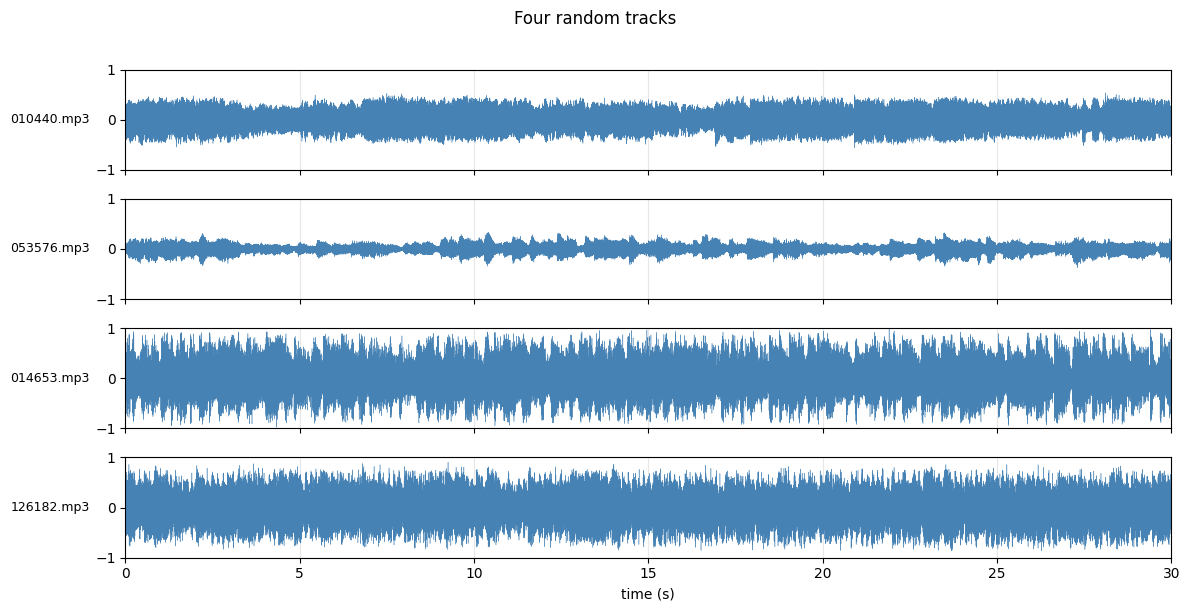

In [3]:
random.seed(123)
sample_idx = random.sample(range(len(all_paths)), 4)

fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)
for ax, idx in zip(axes, sample_idx):
    y_i = fp.load_audio(all_paths[idx])
    t = np.arange(len(y_i)) / sr
    ax.plot(t, y_i, lw=0.3, color="steelblue")
    ax.set_ylabel(Path(all_paths[idx]).name, rotation=0,
                  ha="right", va="center", fontsize=9)
    ax.set_xlim(0, 30)
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Four random tracks", y=1.01)
plt.tight_layout(); plt.show()

### Track-level audio features

Computed on a 150-track random sample:

- **RMS energy (dB)** — track loudness
- **Spectral centroid (Hz)** — brightness, where energy concentrates in frequency
- **Zero-crossing rate** — proxy for percussiveness / noisiness

features:   0%|          | 0/150 [00:00<?, ?it/s]

Features computed on 150 tracks
  duration : median=30.0s (std=0.01s)
  RMS      : median=-15.5 dB [-36.1, -1.8]
  centroid : median=1877 Hz [382, 3415]
  ZCR      : median=0.073


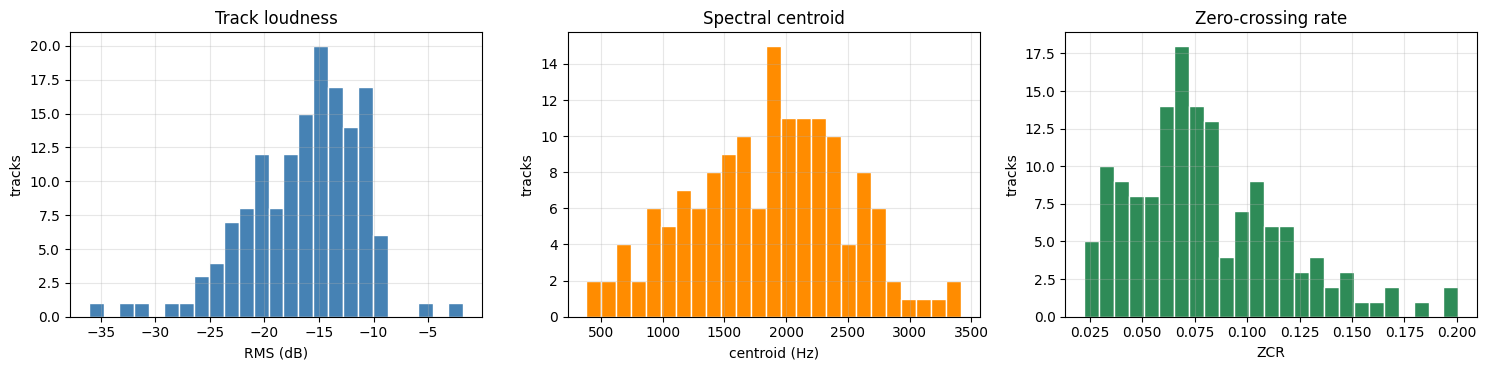

In [4]:
N_SAMPLE = 150
random.seed(0)
sample_paths = random.sample(all_paths, N_SAMPLE)

rms_db, centroid_hz, zcr, durations = [], [], [], []
for p in tqdm(sample_paths, desc="features"):
    try:
        y_i = fp.load_audio(p)
        if len(y_i) < sr:
            continue
        durations.append(len(y_i) / sr)
        rms = librosa.feature.rms(y=y_i).mean()
        rms_db.append(20 * np.log10(rms + 1e-10))
        centroid_hz.append(librosa.feature.spectral_centroid(y=y_i, sr=sr).mean())
        zcr.append(librosa.feature.zero_crossing_rate(y=y_i).mean())
    except Exception:
        continue

print(f"Features computed on {len(rms_db)} tracks")
print(f"  duration : median={np.median(durations):.1f}s "
      f"(std={np.std(durations):.2f}s)")
print(f"  RMS      : median={np.median(rms_db):.1f} dB "
      f"[{np.min(rms_db):.1f}, {np.max(rms_db):.1f}]")
print(f"  centroid : median={np.median(centroid_hz):.0f} Hz "
      f"[{np.min(centroid_hz):.0f}, {np.max(centroid_hz):.0f}]")
print(f"  ZCR      : median={np.median(zcr):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(rms_db, bins=25, color="steelblue", edgecolor="white")
axes[0].set(title="Track loudness", xlabel="RMS (dB)", ylabel="tracks")
axes[0].grid(alpha=0.3)
axes[1].hist(centroid_hz, bins=25, color="darkorange", edgecolor="white")
axes[1].set(title="Spectral centroid", xlabel="centroid (Hz)", ylabel="tracks")
axes[1].grid(alpha=0.3)
axes[2].hist(zcr, bins=25, color="seagreen", edgecolor="white")
axes[2].set(title="Zero-crossing rate", xlabel="ZCR", ylabel="tracks")
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Average spectrogram

Mean STFT magnitude across a 60-track sample. Reveals the typical
time-frequency footprint we will be extracting peaks from.

spectrograms:   0%|          | 0/60 [00:00<?, ?it/s]

Averaged 34 spectrograms


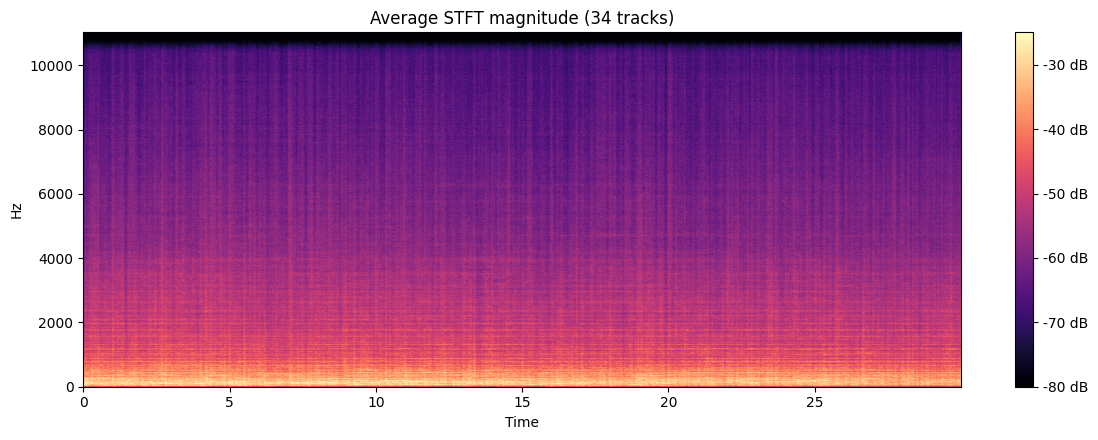

In [5]:
N_MEAN = 60
random.seed(1)
mean_paths = random.sample(all_paths, N_MEAN)

stack = []
target_frames = None
for p in tqdm(mean_paths, desc="spectrograms"):
    try:
        y_i = fp.load_audio(p, duration=30)
        S = fp.compute_spectrogram(y_i)
        if target_frames is None:
            target_frames = S.shape[1]
        if S.shape[1] >= target_frames:
            stack.append(S[:, :target_frames])
    except Exception:
        continue

mean_spec = np.mean(np.stack(stack), axis=0)
print(f"Averaged {len(stack)} spectrograms")

fig, ax = plt.subplots(figsize=(12, 4.5))
img = librosa.display.specshow(
    mean_spec, sr=sr, hop_length=fp.HOP_LENGTH,
    x_axis="time", y_axis="hz", ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB")
ax.set(title=f"Average STFT magnitude ({len(stack)} tracks)", ylim=(0, sr/2))
plt.tight_layout(); plt.show()

## 3. Step 1 — Time-domain signal

A track is a 1-D time series sampled at 22 050 Hz.

Track : fma_small/000/000002.mp3
Samples: 660,984  (30.0s @ 22050 Hz)


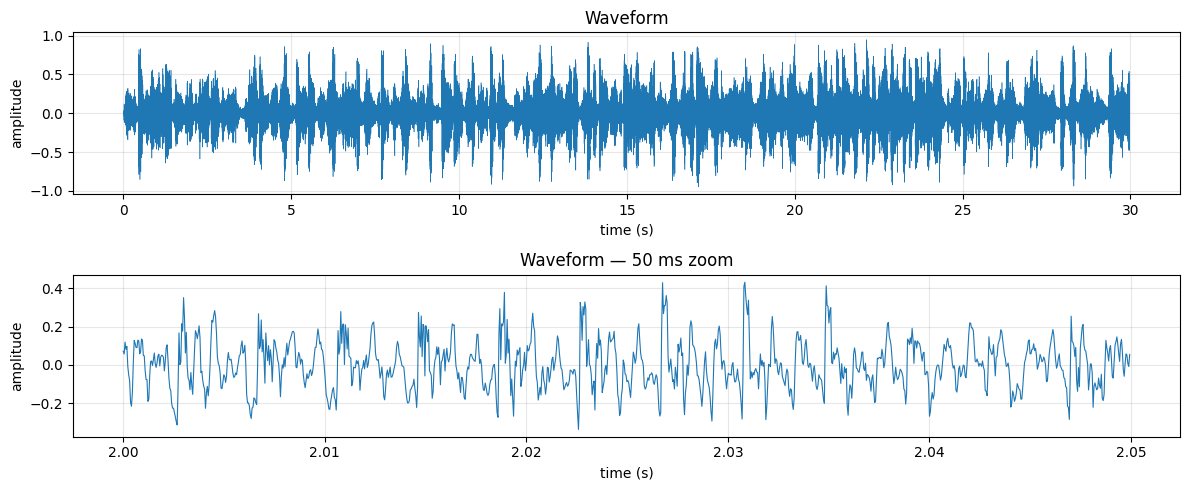

In [6]:
sample_path = all_paths[0]
y = fp.load_audio(sample_path)
duration = len(y) / sr
print(f"Track : {sample_path}")
print(f"Samples: {len(y):,}  ({duration:.1f}s @ {sr} Hz)")

t_axis = np.arange(len(y)) / sr
fig, ax = plt.subplots(2, 1, figsize=(12, 5))
ax[0].plot(t_axis, y, lw=0.4)
ax[0].set(title="Waveform", xlabel="time (s)", ylabel="amplitude")
ax[0].grid(alpha=0.3)

zoom = slice(int(2.0*sr), int(2.05*sr))
ax[1].plot(t_axis[zoom], y[zoom], lw=0.8)
ax[1].set(title="Waveform — 50 ms zoom", xlabel="time (s)", ylabel="amplitude")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Step 2 — Short-Time Fourier Transform

`n_fft = 2048` (~93 ms window), `hop_length = 512` (~23 ms step).
Output shape `(1025 freq bins, n_frames)`.

Spectrogram: (1025, 1291)  (freq_bins, time_frames)


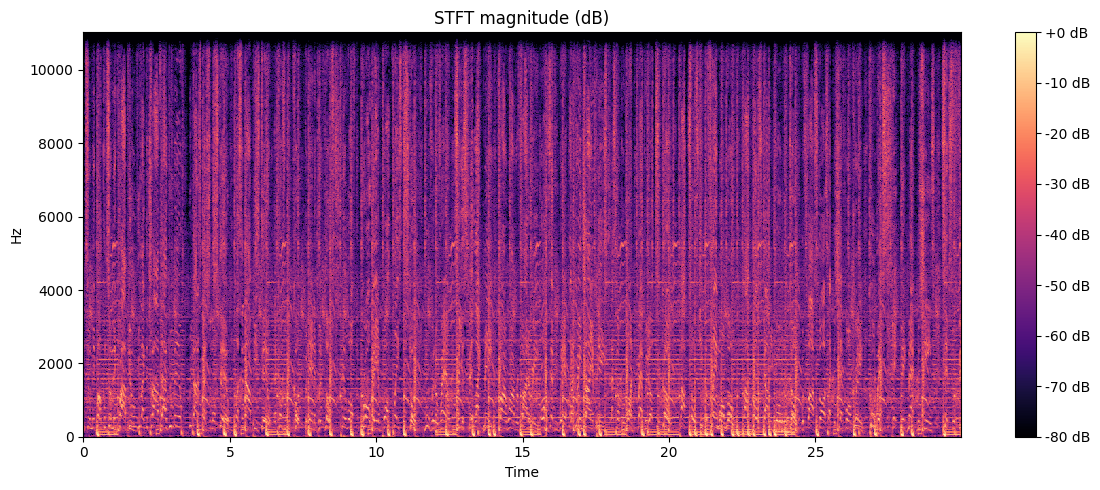

In [7]:
S_db = fp.compute_spectrogram(y)
print(f"Spectrogram: {S_db.shape}  (freq_bins, time_frames)")

fig, ax = plt.subplots(figsize=(12, 5))
img = librosa.display.specshow(
    S_db, sr=sr, hop_length=fp.HOP_LENGTH, x_axis="time", y_axis="hz", ax=ax)
ax.set(title="STFT magnitude (dB)", ylim=(0, sr/2))
fig.colorbar(img, ax=ax, format="%+2.0f dB")
plt.tight_layout(); plt.show()

## 5. Step 3 — Spectral peak detection

Local maxima inside a `(2·20+1) × (2·20+1)` neighborhood, above `-40 dB`.

670 peaks  (0.05% of bins)


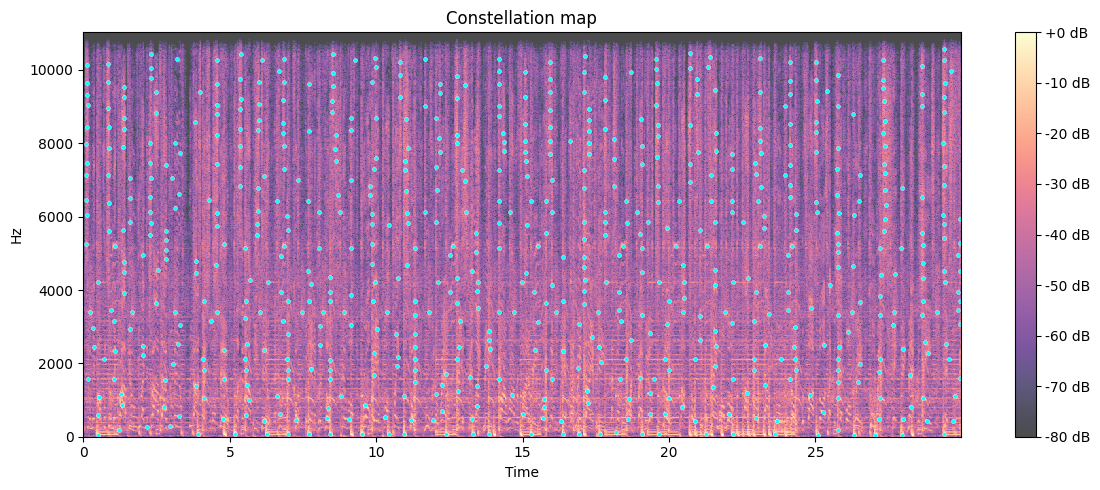

In [8]:
peaks = fp.find_peaks(S_db)
print(f"{len(peaks)} peaks  ({100*len(peaks)/S_db.size:.2f}% of bins)")

t_peak_s  = fp.frames_to_seconds(peaks[:, 1])
f_peak_hz = fp.freq_bin_to_hz(peaks[:, 0])

fig, ax = plt.subplots(figsize=(12, 5))
img = librosa.display.specshow(
    S_db, sr=sr, hop_length=fp.HOP_LENGTH, x_axis="time", y_axis="hz",
    ax=ax, alpha=0.7)
fig.colorbar(img, ax=ax, format="%+2.0f dB")
ax.scatter(t_peak_s, f_peak_hz, s=8, c="cyan",
           edgecolors="white", linewidths=0.3)
ax.set(title="Constellation map", ylim=(0, sr/2))
plt.tight_layout(); plt.show()

## 6. Step 4 — Landmark hashing

Each anchor peak is paired with up to `FANOUT=10` future peaks within the
target zone. Each pair `(f1, f2, dt)` is packed into a 32-bit hash.

6483 hashes from 670 peaks (FANOUT=10)


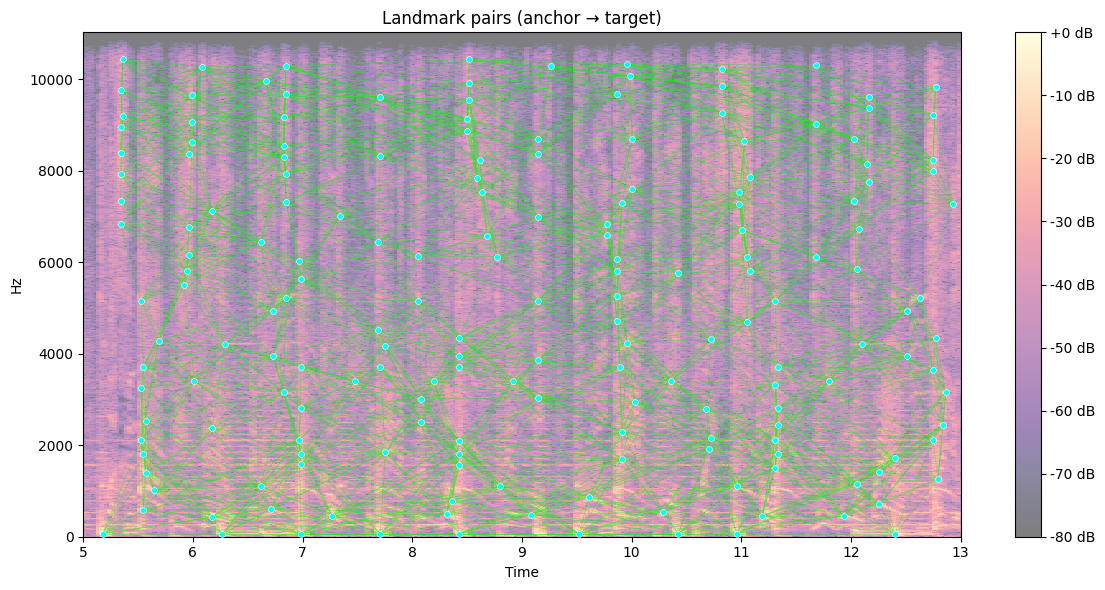

In [9]:
peaks_sorted = peaks[np.lexsort((peaks[:, 0], peaks[:, 1]))]
hashes = fp.make_hashes(peaks_sorted)
print(f"{len(hashes)} hashes from {len(peaks_sorted)} peaks (FANOUT={fp.FANOUT})")

def pairs_for_viz(peaks, fanout=fp.FANOUT,
                  dt_min=fp.TARGET_DT_MIN, dt_max=fp.TARGET_DT_MAX,
                  df_max=fp.TARGET_DF_MAX):
    out = []
    times = peaks[:, 1]; freqs = peaks[:, 0]
    n = len(peaks); j_start = 0
    for i in range(n):
        t1, f1 = times[i], freqs[i]
        while j_start < n and times[j_start] - t1 < dt_min:
            j_start += 1
        paired = 0
        for j in range(j_start, n):
            dt = times[j] - t1
            if dt > dt_max: break
            if abs(int(freqs[j]) - int(f1)) > df_max: continue
            out.append((f1, t1, freqs[j], times[j]))
            paired += 1
            if paired >= fanout: break
    return out

pairs = pairs_for_viz(peaks_sorted)

zoom_lo, zoom_hi = 5.0, 13.0
fig, ax = plt.subplots(figsize=(12, 6))
img = librosa.display.specshow(
    S_db, sr=sr, hop_length=fp.HOP_LENGTH, x_axis="time", y_axis="hz",
    ax=ax, alpha=0.5)
fig.colorbar(img, ax=ax, format="%+2.0f dB")

mask = (t_peak_s >= zoom_lo) & (t_peak_s <= zoom_hi)
ax.scatter(t_peak_s[mask], f_peak_hz[mask], s=18, c="cyan",
           edgecolors="white", linewidths=0.4, zorder=5)

for f1, t1, f2, t2 in pairs:
    t1s = t1 * fp.HOP_LENGTH / sr; t2s = t2 * fp.HOP_LENGTH / sr
    if t1s < zoom_lo or t2s > zoom_hi: continue
    f1h = f1 * sr / fp.N_FFT; f2h = f2 * sr / fp.N_FFT
    ax.plot([t1s, t2s], [f1h, f2h], color="lime", lw=0.4, alpha=0.6)

ax.set(title="Landmark pairs (anchor → target)",
       xlim=(zoom_lo, zoom_hi), ylim=(0, sr/2))
plt.tight_layout(); plt.show()

unique hashes : 6338
hashes appearing >=2 times in track : 99


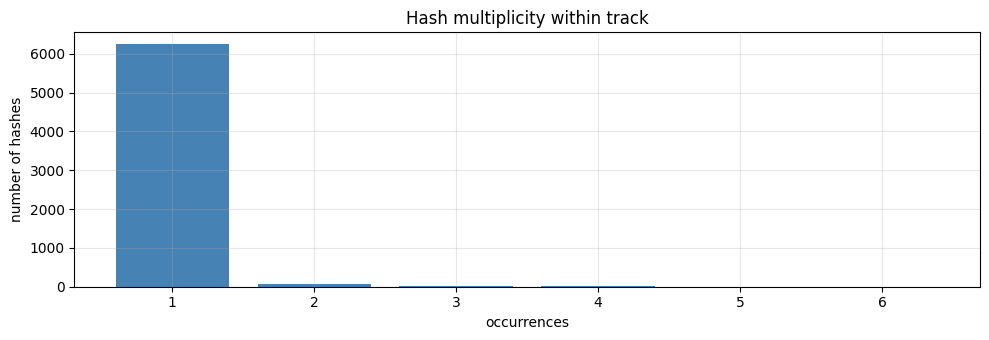

In [10]:
# Hash multiplicity within a single track
hash_ids = [h for h, _ in hashes]
counts = Counter(hash_ids)
print(f"unique hashes : {len(counts)}")
print(f"hashes appearing >=2 times in track : {sum(1 for c in counts.values() if c > 1)}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(list(counts.values()), bins=range(1, 8), align="left",
        rwidth=0.8, color="steelblue")
ax.set(title="Hash multiplicity within track",
       xlabel="occurrences", ylabel="number of hashes")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Step 5 — Build the catalog

Indexing 300 random tracks. Each track contributes ~6 000 (hash, time) entries
to an inverted hash table.

In [11]:
N_CATALOG = 300
random.seed(42)
catalog_paths = random.sample(all_paths, N_CATALOG)

t0 = time.time()
catalog = fp.build_catalog(catalog_paths, verbose=True)
elapsed = time.time() - t0

print(f"\nIndexed {len(catalog.songs)} tracks in {elapsed:.1f}s "
      f"({elapsed/len(catalog.songs):.2f}s/track)")
print(f"unique hashes  : {len(catalog.index):,}")
print(f"total entries  : {catalog.num_hashes():,}")
print(f"avg entries/hash: {catalog.num_hashes()/len(catalog.index):.2f}")

Indexing:   0%|          | 0/300 [00:00<?, ?it/s]

Indexing:   1%|          | 2/300 [00:00<00:28, 10.36it/s]

Indexing:   1%|▏         | 4/300 [00:00<00:28, 10.33it/s]

Indexing:   2%|▏         | 6/300 [00:00<00:44,  6.65it/s]

Indexing:   2%|▏         | 7/300 [00:00<00:43,  6.73it/s]

...

Indexing:  98%|█████████▊| 295/300 [00:21<00:00, 15.75it/s]

Indexing:  99%|█████████▉| 297/300 [00:22<00:00, 11.41it/s]

Indexing: 100%|█████████▉| 299/300 [00:22<00:00, 12.38it/s]

Indexing: 100%|██████████| 300/300 [00:22<00:00, 13.49it/s]


Indexed 300 tracks in 22.2s (0.07s/track)
unique hashes  : 1,155,255
total entries  : 1,347,875
avg entries/hash: 1.17


hashes unique to 1 track : 1,104,246
hashes shared across >5 tracks : 102


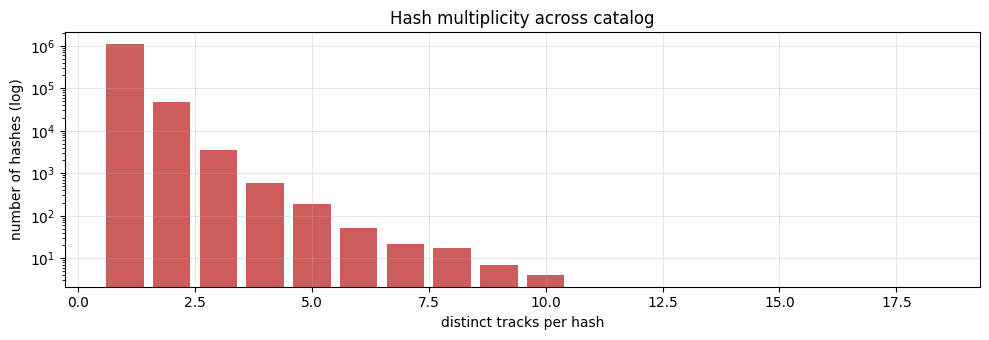

In [12]:
# How many distinct tracks does each hash appear in?
hash_song_counts = [len({s for s, _ in v}) for v in catalog.index.values()]
print(f"hashes unique to 1 track : {sum(1 for c in hash_song_counts if c == 1):,}")
print(f"hashes shared across >5 tracks : {sum(1 for c in hash_song_counts if c > 5):,}")

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(hash_song_counts, bins=np.arange(1, 20),
        align="left", rwidth=0.8, color="indianred")
ax.set(title="Hash multiplicity across catalog",
       xlabel="distinct tracks per hash", ylabel="number of hashes (log)",
       yscale="log")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Step 6 — Match a query

For each query hash, look up DB matches and vote for `t_db - t_query`.
The track whose offset histogram has the tallest peak wins.

In [13]:
truth_id = random.choice(list(catalog.songs.keys()))
truth_path = catalog.songs[truth_id]

QUERY_OFFSET_S = 12.0
QUERY_DUR_S = 8.0
y_query = fp.load_audio(truth_path, duration=QUERY_DUR_S, offset=QUERY_OFFSET_S)

t0 = time.time()
result = fp.match(y_query, catalog)
print(f"Query: {QUERY_DUR_S}s starting at t={QUERY_OFFSET_S}s of track {truth_id}")
print(f"Matched in {time.time()-t0:.3f}s "
      f"({result['query_hashes']} query hashes, {result['query_hash_hits']} DB hits)\n")

print(f"{'rank':<5}{'song_id':<10}{'best_off':<12}{'votes':<10}{'matches':<10}{'file'}")
for r, (sid, votes, off, total) in enumerate(result['ranking'], 1):
    flag = "  <-- truth" if sid == truth_id else ""
    print(f"{r:<5}{sid:<10}{off:<12}{votes:<10}{total:<10}"
          f"{Path(catalog.songs[sid]).name}{flag}")

Query: 8.0s starting at t=12.0s of track 10
Matched in 0.013s (1807 query hashes, 1340 DB hits)

rank song_id   best_off    votes     matches   file
1    10        517         997       1090      116447.mp3  <-- truth
2    241       214         3         8         108962.mp3
3    107       131         2         7         113972.mp3
4    102       1139        2         3         115775.mp3
5    121       110         2         4         117669.mp3


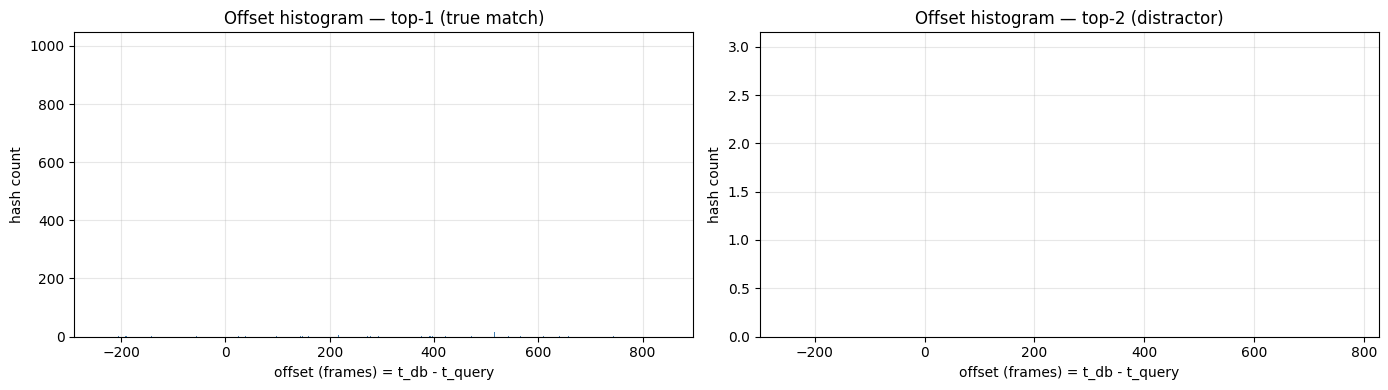

expected offset: 517 frames
observed offset: 517 frames


In [14]:
top_id = result['ranking'][0][0]
distractor_id = result['ranking'][1][0] if len(result['ranking']) > 1 else None

def plot_offset_hist(ax, song_id, title):
    counter = result['votes'].get(song_id, Counter())
    if not counter:
        ax.set_title(f"{title}\n(no matches)")
        return
    offsets = np.array(list(counter.keys()))
    counts = np.array(list(counter.values()))
    order = np.argsort(offsets)
    ax.bar(offsets[order], counts[order], width=1.0, color="steelblue")
    ax.set(title=title, xlabel="offset (frames) = t_db - t_query",
           ylabel="hash count")
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_offset_hist(axes[0], top_id, "Offset histogram — top-1 (true match)")
if distractor_id is not None:
    plot_offset_hist(axes[1], distractor_id, "Offset histogram — top-2 (distractor)")
plt.tight_layout(); plt.show()

expected_offset_frames = QUERY_OFFSET_S * sr / fp.HOP_LENGTH
print(f"expected offset: {expected_offset_frames:.0f} frames")
print(f"observed offset: {result['ranking'][0][2]} frames")

## 9. Step 7 — Robustness evaluation

Top-1 accuracy on 30 in-catalog queries, varying duration and noise.

  10s clean           30/30  (100%)


  10s SNR=10dB        30/30  (100%)


  10s SNR=0dB         30/30  (100%)


  5s clean            30/30  (100%)


  3s clean            30/30  (100%)


  3s SNR=5dB          30/30  (100%)


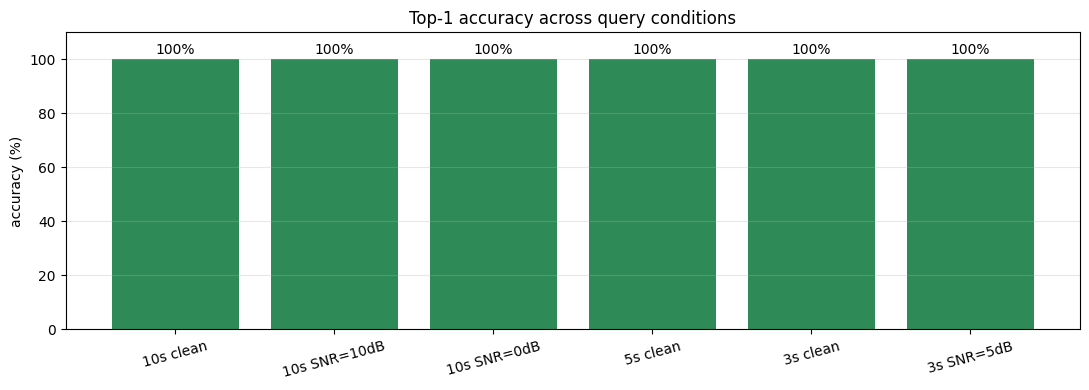

In [15]:
def degrade(y, snr_db=None, duration=None, offset=0.0, sr=fp.SAMPLE_RATE):
    if duration is not None:
        start = int(offset * sr); end = start + int(duration * sr)
        y = y[start:end]
    if snr_db is not None:
        sig_pow = np.mean(y**2)
        noise_pow = sig_pow / (10**(snr_db/10))
        y = y + np.random.randn(len(y)) * np.sqrt(noise_pow)
    return y

random.seed(7)
test_ids = random.sample(list(catalog.songs.keys()), 30)

configs = [
    {"name": "10s clean",       "dur": 10, "off": 5, "snr": None},
    {"name": "10s SNR=10dB",    "dur": 10, "off": 5, "snr": 10},
    {"name": "10s SNR=0dB",     "dur": 10, "off": 5, "snr": 0},
    {"name": "5s clean",        "dur": 5,  "off": 5, "snr": None},
    {"name": "3s clean",        "dur": 3,  "off": 5, "snr": None},
    {"name": "3s SNR=5dB",      "dur": 3,  "off": 5, "snr": 5},
]

results_table = []
for cfg in configs:
    correct = 0
    for sid in test_ids:
        y_full = fp.load_audio(catalog.songs[sid])
        max_off = max(0.0, len(y_full)/sr - cfg["dur"] - 0.5)
        off = min(cfg["off"], max_off)
        y_q = degrade(y_full, snr_db=cfg["snr"], duration=cfg["dur"], offset=off)
        if len(y_q) < sr:
            continue
        r = fp.match(y_q, catalog, top_k=1)
        if r["ranking"] and r["ranking"][0][0] == sid:
            correct += 1
    acc = correct / len(test_ids)
    results_table.append((cfg["name"], correct, len(test_ids), acc))
    print(f"  {cfg['name']:18s}  {correct}/{len(test_ids)}  ({acc*100:.0f}%)")

fig, ax = plt.subplots(figsize=(11, 4))
names = [r[0] for r in results_table]
accs = [r[3]*100 for r in results_table]
bars = ax.bar(names, accs, color="seagreen")
for b, a in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, a+1, f"{a:.0f}%",
            ha="center", va="bottom", fontsize=10)
ax.set(title="Top-1 accuracy across query conditions",
       ylabel="accuracy (%)", ylim=(0, 110))
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 10. Step 8 — Out-of-catalog rejection

A usable system must also recognise queries it doesn't know.
We compare top-1 vote scores for in-catalog vs out-of-catalog queries.

in-catalog  : median=404, min=65, max=862
out-of-catalog: median=3, min=1, max=5


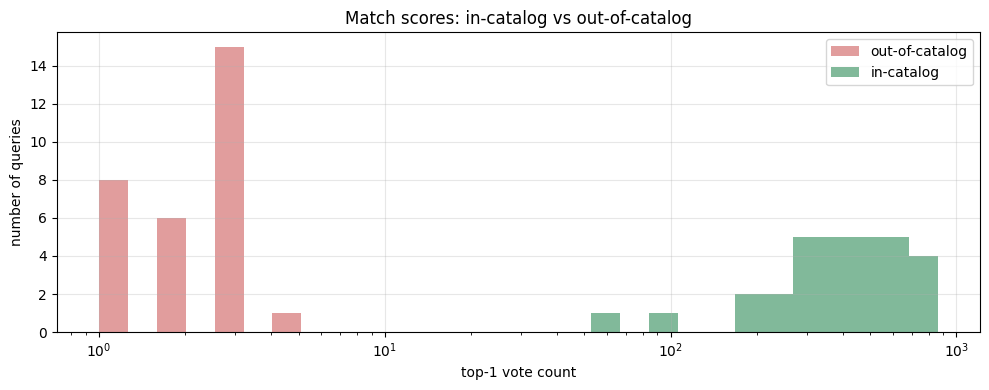

In [16]:
in_catalog = set(catalog.songs.values())
out_paths = [p for p in all_paths if p not in in_catalog]
random.seed(11)
out_sample = random.sample(out_paths, 30)

pos_scores, neg_scores = [], []
for sid in random.sample(list(catalog.songs.keys()), 30):
    y_full = fp.load_audio(catalog.songs[sid], duration=10, offset=5)
    r = fp.match(y_full, catalog, top_k=1)
    if r["ranking"]:
        pos_scores.append(r["ranking"][0][1])

for p in out_sample:
    y_full = fp.load_audio(p, duration=10, offset=5)
    r = fp.match(y_full, catalog, top_k=1)
    neg_scores.append(r["ranking"][0][1] if r["ranking"] else 0)

print(f"in-catalog  : median={np.median(pos_scores):.0f}, "
      f"min={np.min(pos_scores)}, max={np.max(pos_scores)}")
print(f"out-of-catalog: median={np.median(neg_scores):.0f}, "
      f"min={np.min(neg_scores)}, max={np.max(neg_scores)}")

fig, ax = plt.subplots(figsize=(10, 4))
hi = max(max(pos_scores), max(neg_scores)) + 1
bins = np.logspace(0, np.log10(hi), 30)
ax.hist(neg_scores, bins=bins, alpha=0.6, label="out-of-catalog",
        color="indianred")
ax.hist(pos_scores, bins=bins, alpha=0.6, label="in-catalog",
        color="seagreen")
ax.set(xscale="log", xlabel="top-1 vote count",
       ylabel="number of queries",
       title="Match scores: in-catalog vs out-of-catalog")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## References

- Wang, A. (2003). *An Industrial-Strength Audio Search Algorithm.* ISMIR.
- Defferrard, M., Benzi, K., Vandergheynst, P., Bresson, X. (2017).
  *FMA: A Dataset for Music Analysis.* ISMIR.
  [github.com/mdeff/fma](https://github.com/mdeff/fma)